<a href="https://colab.research.google.com/github/arpitathokal/Fake_Job_Detector/blob/main/Suprvised_ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler    # keep non-negative for NB
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, accuracy_score, precision_recall_fscore_support
)
from imblearn.over_sampling import SMOTE
import joblib


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Final_Project_Job_detection/Fake_Job_Detector/models/final_balanced_train.csv")


In [ ]:
#Config

ARTIFACT_DIR  = Path("../models/artifacts_supervised_grid_ensemble")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE  = 42
TEST_SIZE     = 0.2
MAX_TFIDF     = 5000



In [ ]:
#Step 1: Load cleaned data

y = df["fraudulent"].astype(int)

text_cols = [c for c in df.columns if c.endswith("_cleaned")]
num_cols  = [c for c in df.columns if c.endswith("_word_count")]
cat_cols  = ['employment_type','country']

# Combine cleaned text to a single text field
df["combined_text"] = df[text_cols].fillna("").agg(" ".join, axis=1)
X = df[["combined_text"] + num_cols + cat_cols].copy()

print("✅ Feature matrix shape:", X.shape)
print("Columns being used:", X.columns.tolist())

✅ Feature matrix shape: (17880, 7)
Columns being used: ['combined_text', 'description_word_count', 'requirements_word_count', 'benefits_word_count', 'company_profile_word_count', 'employment_type', 'country']


In [ ]:
#TF-IDF transformer is working on one single combined text column that merges:
#description_cleaned
#requirements_cleaned
#benefits_cleaned
#company_profile_cleaned into Combined_text
X

,combined_text,description_word_count,requirements_word_count,benefits_word_count,company_profile_word_count,employment_type,country
0,james beard online food community curated reci...,68,70,0,81,other,us
1,organised focused vibrant awesome passion cust...,188,114,104,95,full-time,nz
2,client located houston actively seeking experi...,30,85,0,76,others,us
3,company esri environmental system research ins...,218,120,66,54,full-time,us
4,job title itemization review managerlocation f...,119,61,3,144,full-time,us
...,...,...,...,...,...,...,...
17875,case first time visited website vend award win...,120,109,68,164,full-time,ca
17876,payroll accountant focus primarily payroll fun...,99,56,41,180,full-time,us
17877,experienced project cost control staff enginee...,113,90,0,19,full-time,us
17878,nemsia studio looking experienced designer joi...,41,46,20,0,contract,ng


In [ ]:
print("data in text column : \n ",df[text_cols[0]])
print("data in numerical column :\n ",df[num_cols[:3]])

data in text column : 
  0        james beard online food community curated reci...
1        organised focused vibrant awesome passion cust...
2        client located houston actively seeking experi...
3        company esri environmental system research ins...
4        job title itemization review managerlocation f...
                               ...                        
17875    case first time visited website vend award win...
17876    payroll accountant focus primarily payroll fun...
17877    experienced project cost control staff enginee...
17878    nemsia studio looking experienced designer joi...
17879    vend award winning web based point sale softwa...
Name: description_cleaned, Length: 17880, dtype: object
data in numerical column :
         description_word_count  requirements_word_count  benefits_word_count
0                          68                       70                    0
1                         188                      114                  104
2            

In [ ]:
#steo 2: Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

In [ ]:
print("Train class distribution:")
print(y_train.value_counts(normalize=True))   #return relative freq by dividing all values by the sum of values
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))


Train class distribution:
fraudulent
0    0.951552
1    0.048448
Name: proportion, dtype: float64

Test class distribution:
fraudulent
0    0.951622
1    0.048378
Name: proportion, dtype: float64


In [ ]:
df.fraudulent.value_counts()

,count
fraudulent,
0,17014
1,866


In [ ]:
print("shape of X train:", X_train.shape)
print("shape of X test:", X_test.shape)

shape of X train: (14304, 7)
shape of X test: (3576, 7)


In [ ]:
#step 3: TF-IDF and preprocessing
# Create transformers for text and numerical features
text_transformer = TfidfVectorizer(max_features=MAX_TFIDF, stop_words="english",dtype=np.float32 )
num_transformer  = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler()),                 # [0,1]

])
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))

])

preprocessor = ColumnTransformer(
    transformers=[
        ("text", text_transformer, "combined_text"),
        ("num",  num_transformer,  num_cols),
        ("cat",  cat_transformer,  cat_cols),
    ],
    remainder="drop",sparse_threshold=1.0
)

# Fit on train and transform
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print("✅ Shapes (sparse):", X_train_proc.shape, X_test_proc.shape)
print("✅ Sparse type:", type(X_train_proc))

✅ Shapes (sparse): (14304, 5099) (3576, 5099)
✅ Sparse type: <class 'scipy.sparse._csr.csr_matrix'>


In [ ]:
# Get the fitted TF-IDF vectorizer from the preprocessor
tfidf_vectorizer = preprocessor.named_transformers_["text"]

# Get terms and their IDF values
terms = tfidf_vectorizer.get_feature_names_out()
idf_values = tfidf_vectorizer.idf_

# Build a DataFrame to inspect
idf_df = pd.DataFrame({
    "term": terms,
    "idf": idf_values
}).sort_values("idf", ascending=False)

# Show first few rows — highest IDF = rarest terms
print("\nTop terms by IDF (rare terms):")
print(idf_df.head(10))

# Show last few rows — lowest IDF = most common terms
print("\nLowest IDF terms (very common):")
print(idf_df.tail(10))



Top terms by IDF (rare terms):
              term       idf
1803  flashfunders  9.182070
3937      scorebig  9.182070
3272        pixlee  8.958927
3660   reformation  8.958927
1055          cove  8.776606
1280       dilbeck  8.776606
3010       omicron  8.622454
4136          smgi  8.622454
3973      seedcamp  8.622454
4777       veripic  8.622454

Lowest IDF terms (very common):
            term       idf
4930     working  1.776422
2921         new  1.741336
609     business  1.728508
4015     service  1.625250
4103       skill  1.608282
4952        year  1.547008
861      company  1.437933
4439        team  1.367267
4924        work  1.319573
1662  experience  1.210208


In [ ]:
# Get the fitted TF-IDF vectorizer
tfidf_vectorizer = preprocessor.named_transformers_["text"]

# Pick the first training row
row_index = 0
raw_text = X_train.iloc[row_index]["combined_text"]

print("Original combined text:\n", raw_text, "\n")

# Transform that single row into TF-IDF vector
row_vector = tfidf_vectorizer.transform([raw_text])

# Feature names
terms = tfidf_vectorizer.get_feature_names_out()

# Build document frequency counts from the entire training set
from collections import Counter
df_counts = Counter()
for doc in X_train["combined_text"]:
    tokens = set(tfidf_vectorizer.build_analyzer()(doc))
    df_counts.update(tokens)

# Get nonzero indices for terms that appear in this row
import numpy as np
nonzero_indices = row_vector.nonzero()[1]

# Gather term data: term, tf-idf weight in this row, DF, IDF
term_data = []
for idx in nonzero_indices:
    term = terms[idx]
    weight = row_vector[0, idx]
    dfreq = df_counts[term]
    idf_value = tfidf_vectorizer.idf_[idx]
    term_data.append((term, weight, dfreq, idf_value))

# Sort by TF-IDF weight descending
term_data_sorted = sorted(term_data, key=lambda x: x[1], reverse=True)

# Show nicely
print(f"{'Term':20} {'TF-IDF':>8} {'DocFreq':>8} {'IDF':>8}")
for term, weight, dfreq, idf_value in term_data_sorted:
    print(f"{term:20} {weight:8.4f} {dfreq:8d} {idf_value:8.4f}")

#DocFreq = number of training documents the term appears in.
#IDF = inverse document frequency, higher if DocFreq is small.
#TF-IDF weight = combines term frequency in this row with its IDF — so rare, frequent-in-this-doc words get the largest weights.

Original combined text:
 tidewater finance company located virginia beach va full position available contact center representative provide diverse lending solution dealer network promoting employee integrity teamwork uncompromised level customer service position requires following qualification minimum year call center environment equivalent customer service experience collection experience plus ability communicate effectively professionally verbally writingproficient typing skillsmust able work late night saturday scheduled managementautomatic dialer experience plusstrong negotiation skillsbilingual spanish plus primary responsibility include limited following make receive call automated dialertake payment past due accountshandle customer service related issuesprocess related paperworkadherence company policy procedure addition compliance state federal regulation offer competitive salary based experience comprehensive benefit package interested candidate may apply person indian river 

In [ ]:
#step4: SMOTE on training only

smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_proc.toarray(), y_train)
X_test_dense = X_test_proc.toarray()  # keep test untouched, just dense for predict_proba

print("Train class distribution BEFORE SMOTE:", y_train.value_counts().to_dict())
print("Train class distribution AFTER  SMOTE:", pd.Series(y_train_bal).value_counts().to_dict())


Train class distribution BEFORE SMOTE: {0: 13611, 1: 693}
Train class distribution AFTER  SMOTE: {0: 13611, 1: 13611}


Before SMOTE: {np.int64(0): np.int64(3), np.int64(1): np.int64(2)}
After SMOTE: {np.int64(0): np.int64(3), np.int64(1): np.int64(3)}


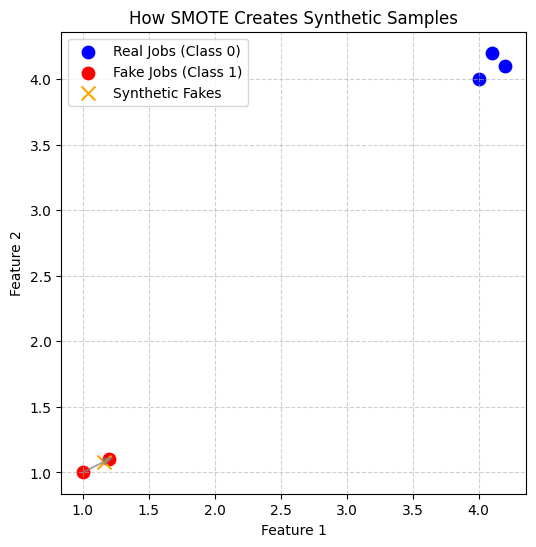

In [ ]:
# Small 2-feature example for easy plotting
# Class 0 = majority (real jobs), Class 1 = minority (fake jobs)
X = np.array([
    [1, 1],     # fake job example 1
    [1.2, 1.1], # fake job example 2
    [4, 4],     # real job example 1
    [4.1, 4.2], # real job example 2
    [4.2, 4.1], # real job example 3
])
y = np.array([1, 1, 0, 0, 0])

print("Before SMOTE:", dict(zip(*np.unique(y, return_counts=True))))

# Apply SMOTE (reduce k_neighbors for tiny dataset)
sm = SMOTE(random_state=42, k_neighbors=1)
X_res, y_res = sm.fit_resample(X, y)

print("After SMOTE:", dict(zip(*np.unique(y_res, return_counts=True))))

# Plot original points
plt.figure(figsize=(6, 6))
plt.scatter(X[y==0, 0], X[y==0, 1], label="Real Jobs (Class 0)", c="blue", s=80)
plt.scatter(X[y==1, 0], X[y==1, 1], label="Fake Jobs (Class 1)", c="red", s=80)

# Find synthetic points (only the new ones)
new_points = X_res[len(X):]

# Plot synthetic points
plt.scatter(new_points[:, 0], new_points[:, 1],
            label="Synthetic Fakes", c="orange", marker="x", s=100)

# Draw arrows from original fake to synthetic point
for synth in new_points:
    # pick a close original fake for arrow start (first one found)
    start = X[y==1][0]
    plt.arrow(start[0], start[1],
              synth[0] - start[0],
              synth[1] - start[1],
              color="gray", alpha=0.6, width=0.005, head_width=0.05)

plt.legend()
plt.title("How SMOTE Creates Synthetic Samples")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


In [ ]:
print(type(X_train_proc), X_train_proc.shape)


<class 'scipy.sparse._csr.csr_matrix'> (14304, 5099)


In [ ]:
#step5: Model training with GridSearchCV

# Naive Bayes
nb_grid = {
    "alpha": [0.5, 1.0, 1.5]
}
nb_gs = GridSearchCV(MultinomialNB(), nb_grid, cv=5, scoring="f1", n_jobs=-1)
nb_gs.fit(X_train_bal, y_train_bal)
nb_best = nb_gs.best_estimator_
print("Best NB params:", nb_gs.best_params_)

# Logistic Regression
lr_grid = {
    "C": [0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}
lr_gs = GridSearchCV(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                     lr_grid, cv=5, scoring="f1", n_jobs=-1)
lr_gs.fit(X_train_bal, y_train_bal)
lr_best = lr_gs.best_estimator_
print("Best LR params:", lr_gs.best_params_)

# Decision Tree
dt_grid = {
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}
dt_gs = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE),
                     dt_grid, cv=5, scoring="f1", n_jobs=-1)
dt_gs.fit(X_train_bal, y_train_bal)
dt_best = dt_gs.best_estimator_
print("Best DT params:", dt_gs.best_params_)

# Random Forest
rf_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}
rf_gs = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
                     rf_grid, cv=5, scoring="f1", n_jobs=-1)
rf_gs.fit(X_train_bal, y_train_bal)
rf_best = rf_gs.best_estimator_
print("Best RF params:", rf_gs.best_params_)

Best NB params: {'alpha': 0.5}
Best LR params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best DT params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
#step6: Voting Classifier
voting = VotingClassifier(
    estimators=[("nb", nb_best), ("lr", lr_best), ("dt", dt_best), ("rf", rf_best)],
    voting="soft",
    weights=[1, 2, 1, 2]
voting.fit(X_train_bal, y_train_bal)

VotingClassifier(estimators=[('nb', MultinomialNB(alpha=0.5)),
                             ('lr',
                              LogisticRegression(C=10, max_iter=1000,
                                                 random_state=42)),
                             ('dt', DecisionTreeClassifier(random_state=42)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     n_estimators=200,
                                                     random_state=42))],
                 voting='soft', weights=[1, 2, 1, 2])

In [ ]:
# Pick one example from the test set
sample_index = 0
X_sample = X_test_dense[sample_index].reshape(1, -1)
y_true = y_test.iloc[sample_index]

# Get probabilities from each model in the ensemble
probs = []
model_names = []
for name, model in voting.named_estimators_.items():
    if hasattr(model, "predict_proba"):
        p_fake = model.predict_proba(X_sample)[0, 1]  # probability for class 1 (fake)
    else:
        p_fake = None
    probs.append(p_fake)
    model_names.append(name)

# Show each model's probability
print("True label:", y_true)
print("\nModel Probabilities for 'Fake':")
for name, p in zip(model_names, probs):
    print(f"{name:>10}: {p:.4f}")

# Apply weights
weights = np.array([1, 2, 1, 2])  # same as your ensemble definition
weighted_avg = np.average(probs, weights=weights)

print("\nWeighted Average Probability:", weighted_avg)
print("Final Prediction:", 1 if weighted_avg >= 0.5 else 0)




True label: 0

Model Probabilities for 'Fake':
        nb: 0.8267
        lr: 0.7306
        dt: 0.0000
        rf: 0.2300

Weighted Average Probability: 0.45797865531450666
Final Prediction: 0


In [ ]:
import seaborn as sns

def eval_model(name, model, X_te_dense, y_te, proba=None):
    """Evaluate a classifier; returns metrics and ROC components, plots styled confusion matrix."""
    # Predictions
    y_pred = model.predict(X_te_dense)
    acc = accuracy_score(y_te, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_te, y_pred, average="binary", zero_division=0)

    # Print classification report
    print(f"\n=== {name} ===")
    print(classification_report(y_te, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_te, y_pred, labels=[0, 1])
    cm_df = pd.DataFrame(cm, index=["Actual Real (0)", "Actual Fake (1)"],
                              columns=["Predicted Real (0)", "Predicted Fake (1)"])

    # Plot heatmap
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="YlGnBu",
                annot_kws={"size": 14, "weight": "bold"}, cbar=False, linewidths=0.5, linecolor="gray")

    plt.title(f"{name} — Confusion Matrix", fontsize=14, weight='bold', pad=12)
    plt.ylabel("True Label", fontsize=12)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.xticks(rotation=0, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()

    # ROC / AUC
    if proba is None and hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_te_dense)[:, 1]

    roc_auc = None
    fpr = tpr = None
    if proba is not None:
        fpr, tpr, _ = roc_curve(y_te, proba)
        roc_auc = auc(fpr, tpr)

    return {
        "name": name,
        "accuracy": acc, "precision": p, "recall": r, "f1": f1,
        "roc_auc": roc_auc, "fpr": fpr, "tpr": tpr,
        "y_pred": y_pred, "proba": proba
    }


=== Naive Bayes (best) ===
              precision    recall  f1-score   support

           0     0.9932    0.9445    0.9682      3403
           1     0.4441    0.8728    0.5887       173

    accuracy                         0.9410      3576
   macro avg     0.7187    0.9086    0.7785      3576
weighted avg     0.9666    0.9410    0.9499      3576



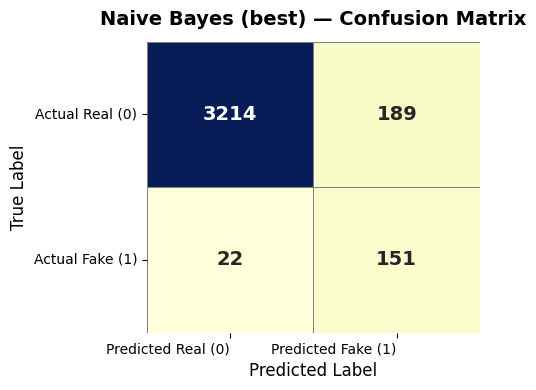


=== Logistic Regression (best) ===
              precision    recall  f1-score   support

           0     0.9941    0.9888    0.9915      3403
           1     0.8010    0.8844    0.8407       173

    accuracy                         0.9838      3576
   macro avg     0.8976    0.9366    0.9161      3576
weighted avg     0.9848    0.9838    0.9842      3576



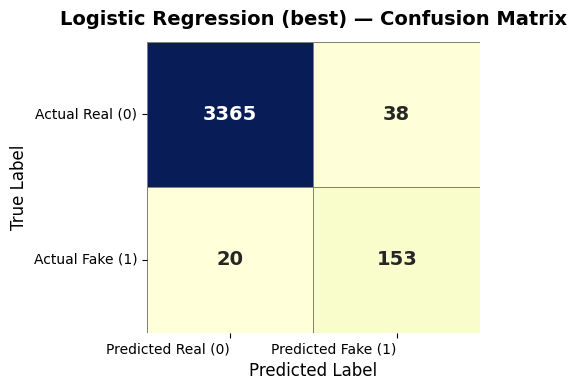


=== Decision Tree (best) ===
              precision    recall  f1-score   support

           0     0.9869    0.9712    0.9790      3403
           1     0.5683    0.7457    0.6450       173

    accuracy                         0.9603      3576
   macro avg     0.7776    0.8584    0.8120      3576
weighted avg     0.9666    0.9603    0.9628      3576



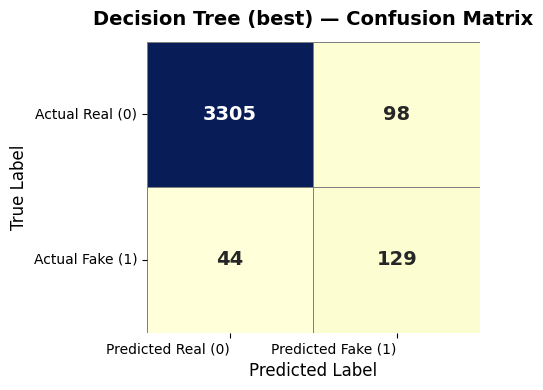


=== Random Forest (best) ===
              precision    recall  f1-score   support

           0     0.9844    0.9997    0.9920      3403
           1     0.9917    0.6879    0.8123       173

    accuracy                         0.9846      3576
   macro avg     0.9880    0.8438    0.9021      3576
weighted avg     0.9847    0.9846    0.9833      3576



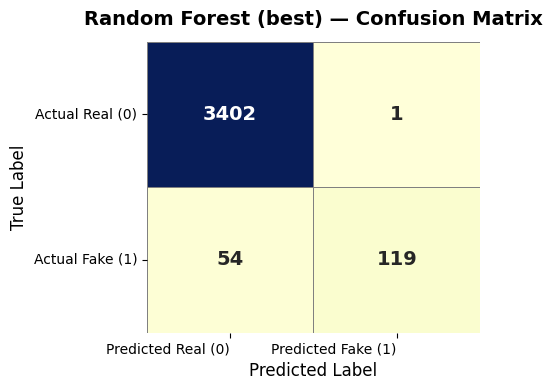


=== Soft Voting (NB+LR+DT+RF) ===
              precision    recall  f1-score   support

           0     0.9912    0.9941    0.9927      3403
           1     0.8773    0.8266    0.8512       173

    accuracy                         0.9860      3576
   macro avg     0.9343    0.9104    0.9219      3576
weighted avg     0.9857    0.9860    0.9858      3576



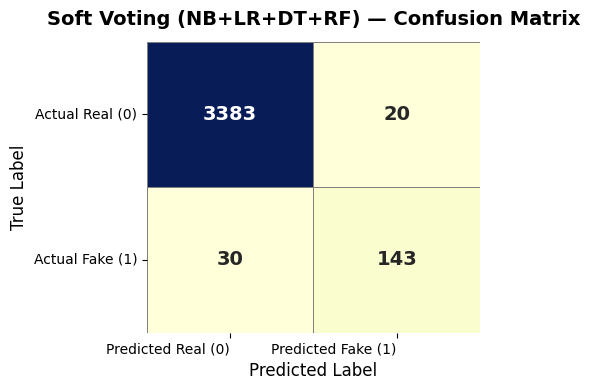

In [ ]:
#step 8 : Evaluate models and voting ensemble
nb_probs = nb_best.predict_proba(X_test_dense)[:, 1]
lr_probs = lr_best.predict_proba(X_test_dense)[:, 1]
dt_probs = dt_best.predict_proba(X_test_dense)[:, 1]
rf_probs = rf_best.predict_proba(X_test_dense)[:, 1]
v_probs  = voting.predict_proba(X_test_dense)[:, 1]

results = []
results.append(eval_model("Naive Bayes (best)", nb_best, X_test_dense, y_test, nb_probs))
results.append(eval_model("Logistic Regression (best)", lr_best, X_test_dense, y_test, lr_probs))
results.append(eval_model("Decision Tree (best)", dt_best, X_test_dense, y_test, dt_probs))
results.append(eval_model("Random Forest (best)", rf_best, X_test_dense, y_test, rf_probs))
results.append(eval_model("Soft Voting (NB+LR+DT+RF)", voting, X_test_dense, y_test, v_probs))


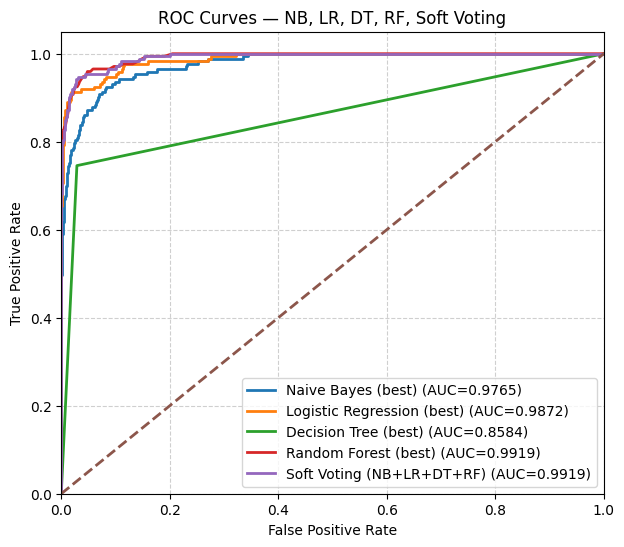

In [ ]:

#step 9: Plot ROC curves for all models
plt.figure(figsize=(7,6))
for res in results:
    if res["roc_auc"] is not None:
        plt.plot(res["fpr"], res["tpr"], lw=2, label=f"{res['name']} (AUC={res['roc_auc']:.4f})")
plt.plot([0,1], [0,1], lw=2, linestyle="--")
plt.xlim([0,1]); plt.ylim([0,1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — NB, LR, DT, RF, Soft Voting")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


In [ ]:
#step10 : Metrics comparison table
metrics_df = pd.DataFrame([
    {k: res[k] for k in ["name","accuracy","precision","recall","f1","roc_auc"]}
    for res in results
]).sort_values("f1", ascending=False)
print("\n=== Metrics Comparison ===")
print(metrics_df.to_string(index=False))




=== Metrics Comparison ===
                      name  accuracy  precision   recall       f1  roc_auc
 Soft Voting (NB+LR+DT+RF)  0.986018   0.877301 0.826590 0.851190 0.991923
Logistic Regression (best)  0.983781   0.801047 0.884393 0.840659 0.987177
      Random Forest (best)  0.984620   0.991667 0.687861 0.812287 0.991936
      Decision Tree (best)  0.960291   0.568282 0.745665 0.645000 0.858433
        Naive Bayes (best)  0.940996   0.444118 0.872832 0.588694 0.976505


/tmp/ipython-input-1540955808.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


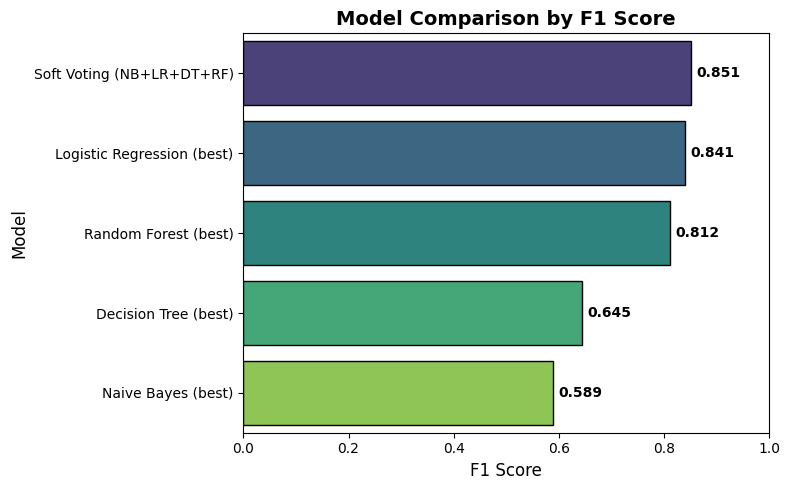

In [ ]:

# Plot horizontal bar chart of F1 scores
plt.figure(figsize=(8, 5))
sns.barplot(
    data=metrics_df,
    x="f1", y="name", palette="viridis", edgecolor="black"
)
plt.title("Model Comparison by F1 Score", fontsize=14, weight="bold")
plt.xlabel("F1 Score", fontsize=12)
plt.ylabel("Model", fontsize=12)
plt.xlim(0, 1)  # since F1 is between 0 and 1
for i, v in enumerate(metrics_df["f1"]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=10, weight="bold")
plt.tight_layout()
plt.show()


In [ ]:
import os, json, joblib
import pandas as pd

# Point ARTIFACT_DIR to your Drive models folder
ARTIFACT_DIR = Path("/content/drive/MyDrive/Final_Project_Job_detection/Fake_Job_Detector/models")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Save preprocessor + models
joblib.dump(preprocessor, ARTIFACT_DIR / "preprocessor.pkl")
joblib.dump(nb_best,       ARTIFACT_DIR / "nb.pkl")
joblib.dump(lr_best,       ARTIFACT_DIR / "lr.pkl")
joblib.dump(dt_best,       ARTIFACT_DIR / "dt.pkl")
joblib.dump(rf_best,       ARTIFACT_DIR / "rf.pkl")
joblib.dump(voting,        ARTIFACT_DIR / "voting_soft.pkl")

# Save metrics & meta
metrics_df.to_csv(ARTIFACT_DIR / "metrics_comparison.csv", index=False)
meta = {
    "combined_text_col": "combined_text",
    "text_cols_used": text_cols,
    "categorical_cols_used": cat_cols,
    "numeric_cols_used": num_cols,
    "max_tfidf_features": MAX_TFIDF,
    "random_state": RANDOM_STATE,
    "models": ["NB", "LR", "DT", "RF", "Voting(soft)"],
    "grids": {
        "NB": nb_grid, "LR": lr_grid, "DT": dt_grid, "RF": rf_grid
    }
}
(ARTIFACT_DIR / "meta.json").write_text(json.dumps(meta, indent=2))

# Save per-row test predictions
preds_df = pd.DataFrame({
    "y_true": y_test,
    "nb_pred": (nb_probs >= 0.5).astype(int),
    "lr_pred": (lr_probs >= 0.5).astype(int),
    "dt_pred": (dt_probs >= 0.5).astype(int),
    "rf_pred": (rf_probs >= 0.5).astype(int),
    "voting_pred": (v_probs >= 0.5).astype(int),
    "nb_proba": nb_probs,
    "lr_proba": lr_probs,
    "dt_proba": dt_probs,
    "rf_proba": rf_probs,
    "voting_proba": v_probs
}, index=X_test.index)
preds_df.to_csv(ARTIFACT_DIR / "test_predictions.csv", index=True)

print(f"\n✅ Saved artifacts to: {ARTIFACT_DIR.resolve()}")




✅ Saved artifacts to: /content/drive/MyDrive/Final_Project_Job_detection/Fake_Job_Detector/models


<Figure size 1100x600 with 0 Axes>

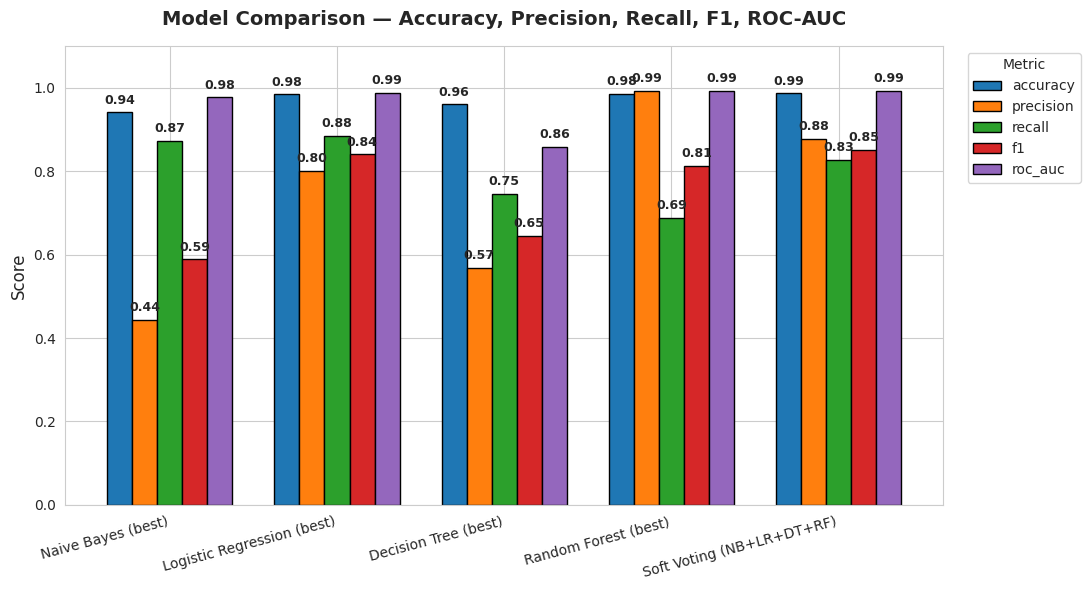

✅ Plot saved to: /content/drive/MyDrive/Final_Project_Job_detection/Fake_Job_Detector/models/model_comparison_bar.png


In [ ]:

# Order and metrics
order = ["Naive Bayes (best)", "Logistic Regression (best)", "Decision Tree (best)",
         "Random Forest (best)", "Soft Voting (NB+LR+DT+RF)"]
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc"]

# Prepare DataFrame in desired order
mdf = (metrics_df
       .set_index("name")
       .reindex(order)
       [metrics_to_plot])

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(11, 6))

# Create grouped bar chart with more distinct colors
ax = mdf.plot(kind="bar", figsize=(11, 6),
              width=0.75,  # increase width from default 0.8
              color=sns.color_palette("tab10", n_colors=len(metrics_to_plot)),
              edgecolor="black")

# Titles and labels
ax.set_ylabel("Score", fontsize=12)
ax.set_xlabel("")
ax.set_ylim(0, 1.1)  # extra headroom for labels
ax.set_title("Model Comparison — Accuracy, Precision, Recall, F1, ROC-AUC",
             fontsize=14, weight="bold", pad=15)

# Legend to the right
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)

# Rotate x-axis labels slightly for readability
plt.xticks(rotation=15, ha="right", fontsize=10)

# Add value labels above bars
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(f"{height:.2f}",
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=9, fontweight="bold",
                    xytext=(0, 4), textcoords='offset points')


# Use the same models folder in Drive
outdir = Path("/content/drive/MyDrive/Final_Project_Job_detection/Fake_Job_Detector/models")
outdir.mkdir(parents=True, exist_ok=True)

# Save figure inside Drive
plt.tight_layout()
plt.savefig(outdir / "model_comparison_bar.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"✅ Plot saved to: {outdir / 'model_comparison_bar.png'}")

In [ ]:
# Pick best model and save as "best"
best_row = metrics_df.sort_values("f1", ascending=False).iloc[0]
best_model_name = best_row["name"]
print(f"✅ Best model: {best_model_name} — F1: {best_row['f1']:.4f}")

model_map = {
    "Naive Bayes (best)": nb_best,
    "Logistic Regression (best)": lr_best,
    "Decision Tree (best)": dt_best,
    "Random Forest (best)": rf_best,
    "Soft Voting (NB+LR+DT+RF)": voting
}
best_model = model_map[best_model_name]

# import joblib, json
# from pathlib import Path
# ARTIFACT_DIR = Path("../models/artifacts_supervised_grid_ensemble")
# ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# joblib.dump(preprocessor, ARTIFACT_DIR / "preprocessor_best.pkl")
# joblib.dump(best_model, ARTIFACT_DIR / "model_best.pkl")
# print(f"💾 Saved preprocessor_best.pkl and model_best.pkl to {ARTIFACT_DIR}")

# Use the same ARTIFACT_DIR in Drive
ARTIFACT_DIR = Path("/content/drive/MyDrive/Final_Project_Job_detection/Fake_Job_Detector/models")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Save preprocessor and best model
joblib.dump(preprocessor, ARTIFACT_DIR / "preprocessor_best.pkl")
joblib.dump(best_model, ARTIFACT_DIR / "model_best.pkl")

print(f"💾 Saved preprocessor_best.pkl and model_best.pkl to {ARTIFACT_DIR}")


✅ Best model: Soft Voting (NB+LR+DT+RF) — F1: 0.8512
💾 Saved preprocessor_best.pkl and model_best.pkl to /content/drive/MyDrive/Final_Project_Job_detection/Fake_Job_Detector/models
